In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

import numpy as np
from tslearn.clustering import TimeSeriesKMeans
from tslearn.datasets import CachedDatasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, \
    TimeSeriesResampler
import seaborn as sns
from tslearn.utils import to_time_series_dataset
from tslearn.clustering import silhouette_score

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score 
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import sklearn.cluster

import os
from yellowbrick.cluster import SilhouetteVisualizer

import math
import scipy

from sklearn.metrics import adjusted_rand_score

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from tslearn.metrics import soft_dtw

In [2]:
def ts_cluster_visualization(y_pred, df, n_clusters, plot_title):
    ts_size = df.shape[1]
    ts_max = df.max()
    plt.figure()
    for cluster in range(n_clusters):
        plt.subplot(4, math.ceil(n_clusters/4), cluster+1)
        for ts in df[y_pred == cluster]:
            plt.plot(ts.ravel(), "k-", alpha=.2)
        plt.plot(np.mean(df[y_pred == cluster], axis=0), "r-")
        plt.xlim(0, ts_size)
        plt.ylim(0, ts_max)
        plt.text(0.55, 0.35,'Cluster %d' % (cluster),
                 transform=plt.gca().transAxes)
        if cluster == 1:
            plt.title(plot_title)      
    plt.tight_layout()
    plt.show()

In [3]:
def import_ff_data(filename):
    expected_columns=155
    data = []
    with open(filename, 'r') as file:
        for line in file:
            row = line.strip().split(',')
            if len(row) < expected_columns:
                row += [np.nan] * (expected_columns - len(row))
            data.append(row)
    df = pd.DataFrame(data)
    def fill_last_valid(row):
        for i in range(1, len(row)):
            if pd.isna(row[i]):
                row[i] = row[i - 1]  
        return row
    df_filled = df.apply(fill_last_valid, axis=1)
    return df_filled

# K means only plot

## Get no-embedding baselines

In [4]:
poor = pd.read_csv("SimData/bank_reserves_outputs_poor.csv", header=None)
middle = pd.read_csv("SimData/bank_reserves_outputs_middle.csv", header=None)
rich = pd.read_csv("SimData/bank_reserves_outputs_rich.csv", header=None)

br_combined = pd.concat([poor, middle, rich], axis=1)
br_combined = StandardScaler().fit_transform(br_combined)

k = 7   
kmeans = KMeans(n_clusters=k, random_state=42)
br_baseline_labels = kmeans.fit_predict(br_combined)

C:\Users\met48\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\met48\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\met48\AppData\Local\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\met48\AppData\Local\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\met48\AppData\Local\anaconda3\Lib\subprocess.py",

In [5]:
#distance_br_no_embedding_kmeans = ts_cluster_distance_silhouette(br_baseline_labels, poor.to_numpy(), middle.to_numpy(), rich.to_numpy(), 7)
import sklearn.metrics as m; 
br_none_kmeans = m.silhouette_score(br_combined, br_baseline_labels, metric='euclidean')

In [6]:
ecv_active = pd.read_csv("SimData/epsteinCV_outputs_active.csv", header=None)
ecv_jailed = pd.read_csv("SimData/epsteinCV_outputs_jailed.csv", header=None)
ecv_quiet = pd.read_csv("SimData/epsteinCV_outputs_quiet.csv", header=None)

ecv_combined = pd.concat([ecv_active, ecv_jailed, ecv_quiet], axis=1)
ecv_combined = StandardScaler().fit_transform(ecv_combined)

k = 8   
kmeans = KMeans(n_clusters=k, random_state=42)
ecv_baseline_labels = kmeans.fit_predict(ecv_combined)

In [7]:
ecv_none_kmeans = m.silhouette_score(ecv_combined, ecv_baseline_labels, metric='euclidean')

In [8]:
ff_onfire = import_ff_data("SimData/forest_fire_outputs_onfire.csv")
ff_fine = import_ff_data("SimData/forest_fire_outputs_fine.csv")
ff_burned = import_ff_data("SimData/forest_fire_outputs_burned.csv")

ff_combined = pd.concat([ff_onfire, ff_fine, ff_burned], axis=1)
ff_combined = StandardScaler().fit_transform(ff_combined)

k = 4   
kmeans = KMeans(n_clusters=k, random_state=42)
ff_baseline_labels = kmeans.fit_predict(ff_combined)

In [9]:
ff_none_kmeans = m.silhouette_score(ff_combined, ff_baseline_labels, metric='euclidean')

## PCA

In [10]:
label_results = pd.read_csv('bank_reserves_results.csv', index_col=0)
df = pd.read_csv('extracted_features/bank_reserves_PCA_standardized.csv', index_col=0)
br_pca_kmeans = m.silhouette_score(df, label_results.loc["PCA_KMeans"].to_numpy(), metric='euclidean')

In [11]:
label_results = pd.read_csv('epstein_results.csv', index_col=0)
df = pd.read_csv('extracted_features/epstein_PCA_standardized.csv', index_col=0)
ecv_pca_kmeans = m.silhouette_score(df, label_results.loc["PCA_KMeans"].to_numpy(), metric='euclidean')

In [12]:
label_results = pd.read_csv('forestfire_results.csv', index_col=0)
df = pd.read_csv('extracted_features/forestfire_PCA_standardized.csv', index_col=0)
ff_pca_kmeans = m.silhouette_score(df, label_results.loc["PCA_KMeans"].to_numpy(), metric='euclidean')

## DAE

In [13]:
label_results = pd.read_csv('bank_reserves_results.csv', index_col=0)
df = pd.read_csv('extracted_features/bank_reserves_DAE.csv', header=None)
br_dae_kmeans = m.silhouette_score(df, label_results.loc["DAE_KMeans"].to_numpy(), metric='euclidean')

In [14]:
label_results = pd.read_csv('epstein_results.csv', index_col=0)
df = pd.read_csv('extracted_features/epstein_DAE.csv', header=None)
ecv_dae_kmeans = m.silhouette_score(df, label_results.loc["DAE_KMeans"].to_numpy(), metric='euclidean')

In [15]:
label_results = pd.read_csv('forestfire_results.csv', index_col=0)
df = pd.read_csv('extracted_features/forestfire_DAE.csv', header=None)
ff_dae_kmeans = m.silhouette_score(df, label_results.loc["DAE_KMeans"].to_numpy(), metric='euclidean')

## DCAE

In [16]:
label_results = pd.read_csv('bank_reserves_results.csv', index_col=0)
df = pd.read_csv('extracted_features/bank_reserves_DCAE.csv', header=None)
br_dcae_kmeans = m.silhouette_score(df, label_results.loc["DCAE_KMeans"].to_numpy(), metric='euclidean')

In [17]:
label_results = pd.read_csv('epstein_results.csv', index_col=0)
df = pd.read_csv('extracted_features/epstein_DCAE.csv', header=None)
ecv_dcae_kmeans = m.silhouette_score(df, label_results.loc["DCAE_KMeans"].to_numpy(), metric='euclidean')

In [18]:
label_results = pd.read_csv('forestfire_results.csv', index_col=0)
df = pd.read_csv('extracted_features/forestfire_DCAE.csv', header=None)
ff_dcae_kmeans = m.silhouette_score(df, label_results.loc["DCAE_KMeans"].to_numpy(), metric='euclidean')

## Format

In [19]:
models = ['Bank Reserves', 'Bank Reserves', 'Bank Reserves', 'Bank Reserves', 
                                    'Epstein', 'Epstein', 'Epstein', 'Epstein', 
                                    'Forest Fire', 'Forest Fire', 'Forest Fire', 'Forest Fire']

In [54]:
df_kmeans = pd.DataFrame({'Model': ['Bank Reserves', 'Bank Reserves', 'Bank Reserves', 'Bank Reserves', 
                                    'Epstein', 'Epstein', 'Epstein', 'Epstein', 
                                    'Forest Fire', 'Forest Fire', 'Forest Fire', 'Forest Fire'], 
                        'Feature Embedding': ['None', 'PCA', 'DAE', 'DCAE', 
                                              'None', 'PCA', 'DAE', 'DCAE', 
                                              'None', 'PCA', 'DAE', 'DCAE'], 
                        'Silhouette Score': [br_none_kmeans, br_pca_kmeans, br_dae_kmeans, br_dcae_kmeans,
                                            ecv_none_kmeans, ecv_pca_kmeans, ecv_dae_kmeans, ecv_dcae_kmeans,
                                            ff_none_kmeans, ff_pca_kmeans, ff_dae_kmeans, ff_dcae_kmeans]
                         })

In [55]:
df_kmeans

,Model,Feature Embedding,Silhouette Score
0,Bank Reserves,None,0.187020
1,Bank Reserves,PCA,0.554042
2,Bank Reserves,DAE,0.575032
3,Bank Reserves,DCAE,0.343016
4,Epstein,None,0.381583
5,Epstein,PCA,0.569991
6,Epstein,DAE,0.538432
7,Epstein,DCAE,0.525609
8,Forest Fire,None,0.511961
9,Forest Fire,PCA,0.860563


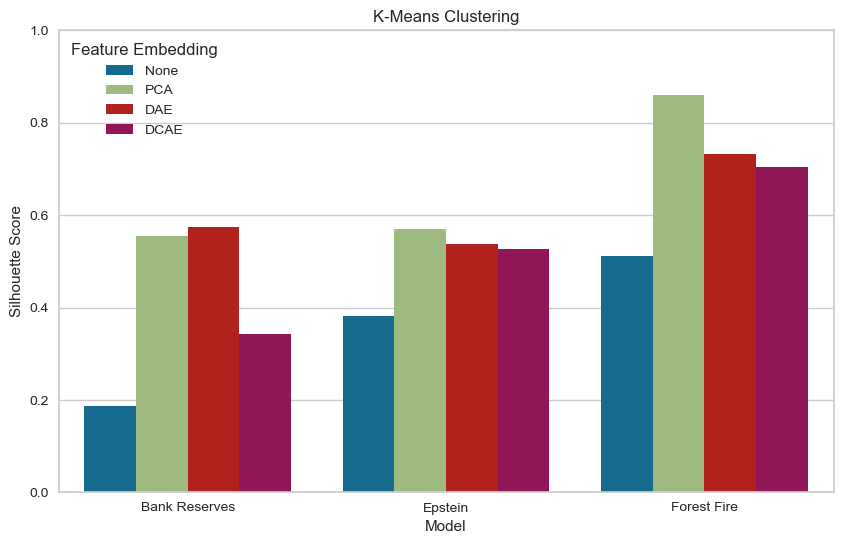

In [21]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_kmeans, x="Model", y="Silhouette Score", hue="Feature Embedding")

# Customize the plot
plt.xlabel("Model")
plt.ylabel("Silhouette Score")
plt.title("K-Means Clustering")
plt.legend(title="Feature Embedding")
plt.ylim(0, 1)
plt.savefig("kmeans_embedding_comp.png", format="png")
plt.show()

# DAE only plot

In [22]:
label_results = pd.read_csv('bank_reserves_results.csv', index_col=0)
df = pd.read_csv('extracted_features/bank_reserves_DAE.csv', header=None)
br_dae_kmeans = m.silhouette_score(df, label_results.loc["DAE_KMeans"].to_numpy(), metric='euclidean')
br_dae_agglom = m.silhouette_score(df, label_results.loc["DAE_Agglom"].to_numpy(), metric='euclidean')
br_dae_spectral = m.silhouette_score(df, label_results.loc["DAE_Spectral"].to_numpy(), metric='euclidean')

In [23]:
label_results = pd.read_csv('epstein_results.csv', index_col=0)
df = pd.read_csv('extracted_features/epstein_DAE.csv', header=None)
ecv_dae_kmeans = m.silhouette_score(df, label_results.loc["DAE_KMeans"].to_numpy(), metric='euclidean')
ecv_dae_agglom = m.silhouette_score(df, label_results.loc["DAE_Agglom"].to_numpy(), metric='euclidean')
ecv_dae_spectral = m.silhouette_score(df, label_results.loc["DAE_Spectral"].to_numpy(), metric='euclidean')

In [24]:
label_results = pd.read_csv('forestfire_results.csv', index_col=0)
df = pd.read_csv('extracted_features/forestfire_DAE.csv', header=None)
ff_dae_kmeans = m.silhouette_score(df, label_results.loc["DAE_KMeans"].to_numpy(), metric='euclidean')
ff_dae_agglom = m.silhouette_score(df, label_results.loc["DAE_Agglom"].to_numpy(), metric='euclidean')
ff_dae_spectral = m.silhouette_score(df, label_results.loc["DAE_Spectral"].to_numpy(), metric='euclidean')

In [43]:
df_dae = pd.DataFrame({'Model': ['Bank Reserves', 'Bank Reserves', 'Bank Reserves', 
                                    'Epstein', 'Epstein', 'Epstein', 
                                    'Forest Fire', 'Forest Fire', 'Forest Fire'], 
                        'Clustering': ['K-Means', 'Agglom', 'Spectral', 
                                              'K-Means', 'Agglom', 'Spectral', 
                                              'K-Means', 'Agglom', 'Spectral'], 
                        'Silhouette Score': [br_dae_kmeans, br_dae_agglom, br_dae_spectral, 
                                            ecv_dae_kmeans, ecv_dae_agglom, ecv_dae_spectral, 
                                            ff_dae_kmeans, ff_dae_agglom, ff_dae_spectral]
                         })

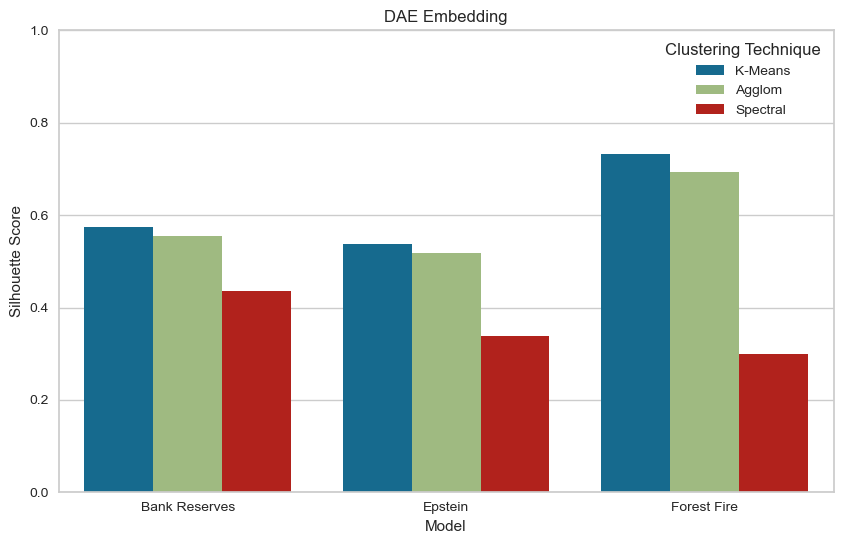

In [44]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_dae, x="Model", y="Silhouette Score", hue="Clustering")

# Customize the plot
plt.xlabel("Model")
plt.ylabel("Silhouette Score")
plt.title("DAE Embedding")
plt.legend(title="Clustering Technique")
plt.ylim(0, 1)
plt.savefig("dae_embedding_comp.png", format="png")
plt.show()

# PCA Only Plot

In [27]:
label_results = pd.read_csv('bank_reserves_results.csv', index_col=0)
df = pd.read_csv('extracted_features/bank_reserves_PCA_standardized.csv', index_col=0)
br_pca_kmeans = m.silhouette_score(df, label_results.loc["PCA_KMeans"].to_numpy(), metric='euclidean')
br_pca_agglom = m.silhouette_score(df, label_results.loc["PCA_Agglom"].to_numpy(), metric='euclidean')
br_pca_spectral = m.silhouette_score(df, label_results.loc["PCA_Spectral"].to_numpy(), metric='euclidean')

In [28]:
df

,0,1,2,3,4,5,6,7,8
0,-11.447759,0.622160,1.470393e-15,12.961041,0.427020,1.470393e-15,-1.513282,-1.049180,1.470393e-15
1,-11.430783,0.601254,-1.882270e-15,12.976787,0.409237,-1.882270e-15,-1.546004,-1.010490,-1.882270e-15
2,-10.891938,0.464872,-6.350579e-16,13.328232,0.249344,-6.350579e-16,-2.436293,-0.714216,-6.350579e-16
3,-11.875962,-0.966930,-2.701414e-15,4.629266,7.064285,-2.701414e-15,7.246696,-6.097355,-2.701414e-15
4,-13.115048,0.829293,6.820752e-16,10.841902,1.489284,6.820752e-16,2.273145,-2.318577,6.820752e-16
...,...,...,...,...,...,...,...,...,...
99995,-10.014664,-4.169437,-6.037893e-16,-0.212350,8.084438,-6.037893e-16,10.227014,-3.915002,-6.037893e-16
99996,-10.893031,1.407198,-1.062553e-15,3.946906,-8.369916,-1.062553e-15,6.946126,6.962718,-1.062553e-15
99997,-13.404599,0.805534,-1.637443e-15,9.434163,2.561654,-1.637443e-15,3.970436,-3.367188,-1.637443e-15
99998,-12.301931,0.952376,-6.346143e-16,12.077006,1.006597,-6.346143e-16,0.224924,-1.958973,-6.346143e-16


In [29]:
label_results = pd.read_csv('epstein_results.csv', index_col=0)
df = pd.read_csv('extracted_features/epstein_PCA_standardized.csv', index_col=0)
ecv_pca_kmeans = m.silhouette_score(df, label_results.loc["PCA_KMeans"].to_numpy(), metric='euclidean')
ecv_pca_agglom = m.silhouette_score(df, label_results.loc["PCA_Agglom"].to_numpy(), metric='euclidean')
ecv_pca_spectral = m.silhouette_score(df, label_results.loc["PCA_Spectral"].to_numpy(), metric='euclidean')

In [30]:
label_results = pd.read_csv('forestfire_results.csv', index_col=0)
df = pd.read_csv('extracted_features/forestfire_PCA_standardized.csv', index_col=0)
ff_pca_kmeans = m.silhouette_score(df, label_results.loc["PCA_KMeans"].to_numpy(), metric='euclidean')
ff_pca_agglom = m.silhouette_score(df, label_results.loc["PCA_Agglom"].to_numpy(), metric='euclidean')
ff_pca_spectral = m.silhouette_score(df, label_results.loc["PCA_Spectral"].to_numpy(), metric='euclidean')

In [41]:
df_pca = pd.DataFrame({'Model': ['Bank Reserves', 'Bank Reserves', 'Bank Reserves', 
                                    'Epstein', 'Epstein', 'Epstein', 
                                    'Forest Fire', 'Forest Fire', 'Forest Fire'], 
                        'Clustering': ['K-Means', 'Agglom', 'Spectral', 
                                              'K-Means', 'Agglom', 'Spectral', 
                                              'K-Means', 'Agglom', 'Spectral'], 
                        'Silhouette Score': [br_pca_kmeans, br_pca_agglom, br_pca_spectral, 
                                            ecv_pca_kmeans, ecv_pca_agglom, ecv_pca_spectral, 
                                            ff_pca_kmeans, ff_pca_agglom, ff_pca_spectral]
                         })

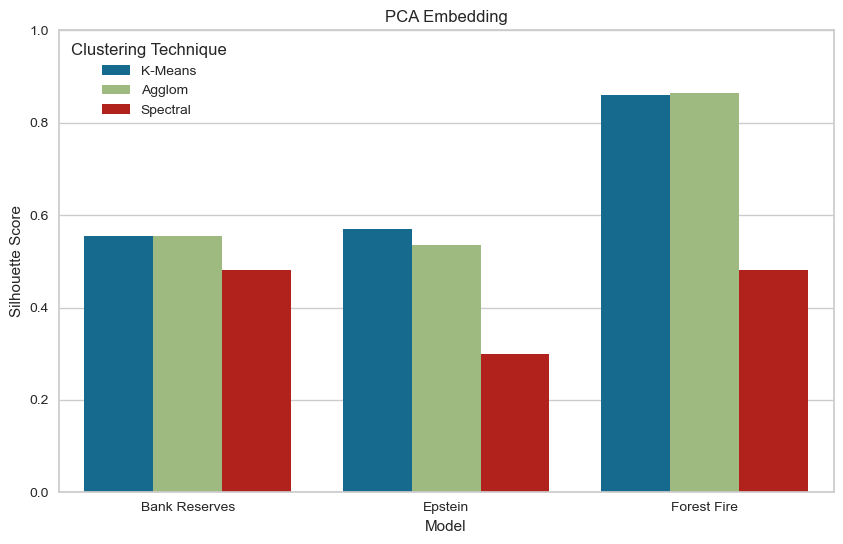

In [42]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_pca, x="Model", y="Silhouette Score", hue="Clustering")

# Customize the plot
plt.xlabel("Model")
plt.ylabel("Silhouette Score")
plt.title("PCA Embedding")
plt.legend(title="Clustering Technique")
plt.ylim(0, 1)
plt.savefig("pca_embedding_comp.png", format="png")
plt.show()

# DCAE only

In [33]:
label_results = pd.read_csv('bank_reserves_results.csv', index_col=0)
df = pd.read_csv('extracted_features/bank_reserves_DCAE.csv', header=None)
br_dcae_kmeans = m.silhouette_score(df, label_results.loc["DCAE_KMeans"].to_numpy(), metric='euclidean')
br_dcae_agglom = m.silhouette_score(df, label_results.loc["DCAE_Agglom"].to_numpy(), metric='euclidean')
br_dcae_spectral = m.silhouette_score(df, label_results.loc["DCAE_Spectral"].to_numpy(), metric='euclidean')

In [34]:
label_results = pd.read_csv('epstein_results.csv', index_col=0)
df = pd.read_csv('extracted_features/epstein_DCAE.csv', header=None)
ecv_dcae_kmeans = m.silhouette_score(df, label_results.loc["DCAE_KMeans"].to_numpy(), metric='euclidean')
ecv_dcae_agglom = m.silhouette_score(df, label_results.loc["DCAE_Agglom"].to_numpy(), metric='euclidean')
ecv_dcae_spectral = m.silhouette_score(df, label_results.loc["DCAE_Spectral"].to_numpy(), metric='euclidean')

In [35]:
label_results = pd.read_csv('forestfire_results.csv', index_col=0)
df = pd.read_csv('extracted_features/forestfire_DCAE.csv', header=None)
ff_dcae_kmeans = m.silhouette_score(df, label_results.loc["DCAE_KMeans"].to_numpy(), metric='euclidean')
ff_dcae_agglom = m.silhouette_score(df, label_results.loc["DCAE_Agglom"].to_numpy(), metric='euclidean')
ff_dcae_spectral = m.silhouette_score(df, label_results.loc["DCAE_Spectral"].to_numpy(), metric='euclidean')

In [39]:
df_dcae = pd.DataFrame({'Model': ['Bank Reserves', 'Bank Reserves', 'Bank Reserves', 
                                    'Epstein', 'Epstein', 'Epstein', 
                                    'Forest Fire', 'Forest Fire', 'Forest Fire'], 
                        'Clustering': ['K-Means', 'Agglom', 'Spectral', 
                                              'K-Means', 'Agglom', 'Spectral', 
                                              'K-Means', 'Agglom', 'Spectral'], 
                        'Silhouette Score': [br_dcae_kmeans, br_dcae_agglom, br_dcae_spectral, 
                                            ecv_dcae_kmeans, ecv_dcae_agglom, ecv_dcae_spectral, 
                                            ff_dcae_kmeans, ff_dcae_agglom, ff_dcae_spectral]
                         })

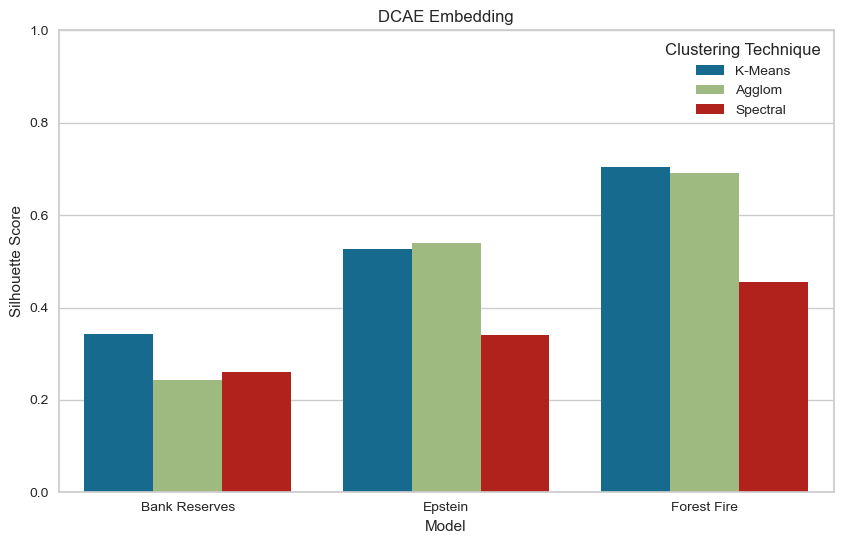

In [40]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_dcae, x="Model", y="Silhouette Score", hue="Clustering")

# Customize the plot
plt.xlabel("Model")
plt.ylabel("Silhouette Score")
plt.title("DCAE Embedding")
plt.legend(title="Clustering Technique")
plt.ylim(0, 1)
plt.savefig("dcae_embedding_comp.png", format="png")
plt.show()

In [46]:
df_pca['Embedding'] = 'PCA'

In [47]:
df_pca

,Model,Clustering,Silhouette Score,Embedding
0,Bank Reserves,K-Means,0.554042,PCA
1,Bank Reserves,Agglom,0.554078,PCA
2,Bank Reserves,Spectral,0.480306,PCA
3,Epstein,K-Means,0.569991,PCA
4,Epstein,Agglom,0.535093,PCA
5,Epstein,Spectral,0.298750,PCA
6,Forest Fire,K-Means,0.860563,PCA
7,Forest Fire,Agglom,0.865222,PCA
8,Forest Fire,Spectral,0.481573,PCA


In [50]:
df_dae['Embedding'] = 'DAE'

In [51]:
df_dae

,Model,Clustering,Silhouette Score,Embedding
0,Bank Reserves,K-Means,0.575032,DAE
1,Bank Reserves,Agglom,0.553857,DAE
2,Bank Reserves,Spectral,0.435693,DAE
3,Epstein,K-Means,0.538432,DAE
4,Epstein,Agglom,0.517790,DAE
5,Epstein,Spectral,0.339192,DAE
6,Forest Fire,K-Means,0.732951,DAE
7,Forest Fire,Agglom,0.693863,DAE
8,Forest Fire,Spectral,0.300344,DAE


In [52]:
df_dcae['Embedding'] = 'DCAE'

In [53]:
df_dcae

,Model,Clustering,Silhouette Score,Embedding
0,Bank Reserves,K-Means,0.343016,DCAE
1,Bank Reserves,Agglom,0.243963,DCAE
2,Bank Reserves,Spectral,0.261383,DCAE
3,Epstein,K-Means,0.525609,DCAE
4,Epstein,Agglom,0.539743,DCAE
5,Epstein,Spectral,0.340720,DCAE
6,Forest Fire,K-Means,0.703295,DCAE
7,Forest Fire,Agglom,0.690143,DCAE
8,Forest Fire,Spectral,0.455774,DCAE


In [60]:
poor = pd.read_csv("SimData/bank_reserves_outputs_poor.csv", header=None)
X_train = to_time_series_dataset(poor)
sz = X_train.shape[1]

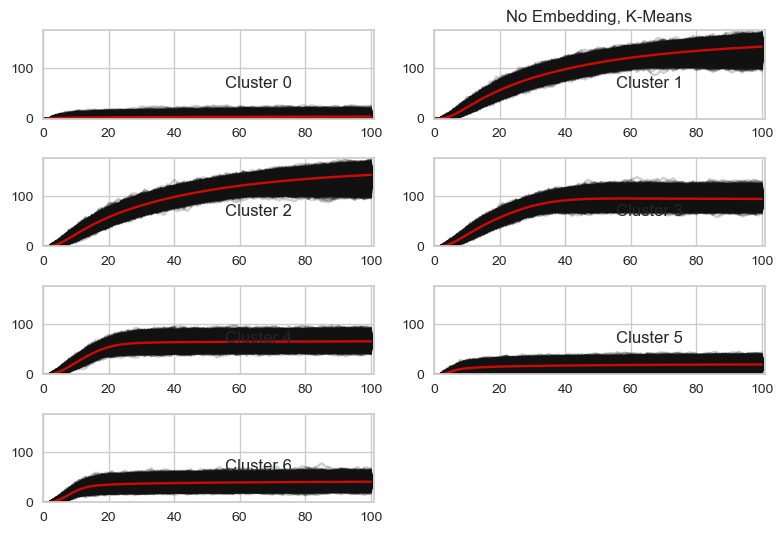

In [61]:
ts_cluster_visualization(br_baseline_labels, X_train, 7, "No Embedding, K-Means")

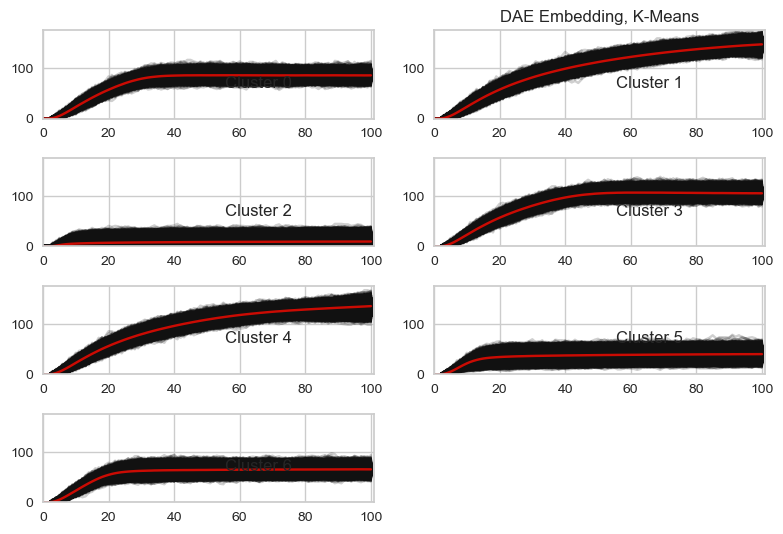

In [64]:
label_results = pd.read_csv('bank_reserves_results.csv', index_col=0)
ts_cluster_visualization(label_results.loc["DAE_KMeans"].to_numpy(), X_train, 7, "DAE Embedding, K-Means")

In [73]:
def ts_cluster_visualization2(y_pred, df, n_clusters, plot_title=None):
    """
    Plot only the cluster center (mean) curves for all clusters on a single plot.

    Parameters
    ----------
    y_pred : array-like of shape (n_samples,)
        Cluster labels for each time series (assumed 0..n_clusters-1).
    df : array-like of shape (n_samples, T)
        Time-series data; rows = series, columns = timesteps.
        Can be a NumPy array or a pandas DataFrame.
    n_clusters : int
        Number of clusters.
    plot_title : str, optional
        Title for the plot.
    """
    # Ensure we can index like a NumPy array
    X = np.asarray(df)
    ts_size = X.shape[1]
    ts_max = np.nanmax(X)

    plt.figure(figsize=(9, 5))
    for c in range(n_clusters):
        mask = (y_pred == c)
        if not np.any(mask):
            continue  # skip empty clusters gracefully
        center = np.nanmean(X[mask], axis=0)
        plt.plot(center.ravel(), linewidth=2, label=f"Cluster {c}")

    plt.xlim(0, ts_size - 1)
    plt.ylim(0, ts_max)
    if plot_title:
        plt.title(plot_title)
    plt.xlabel("Timestep")
    plt.ylabel("Value")
    plt.legend(frameon=False)
    plt.tight_layout()
    #plt.show()

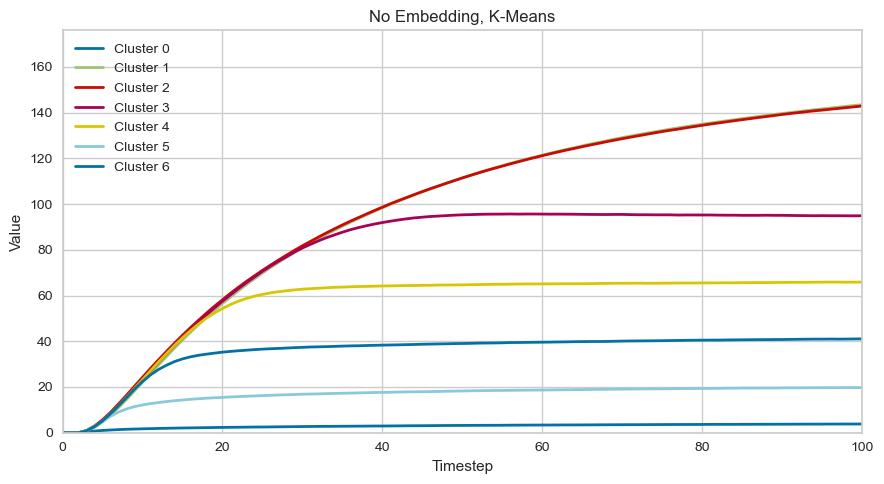

In [74]:
ts_cluster_visualization2(br_baseline_labels, X_train, 7, "No Embedding, K-Means")
plt.savefig("no_embedding_centers.png", format="png")

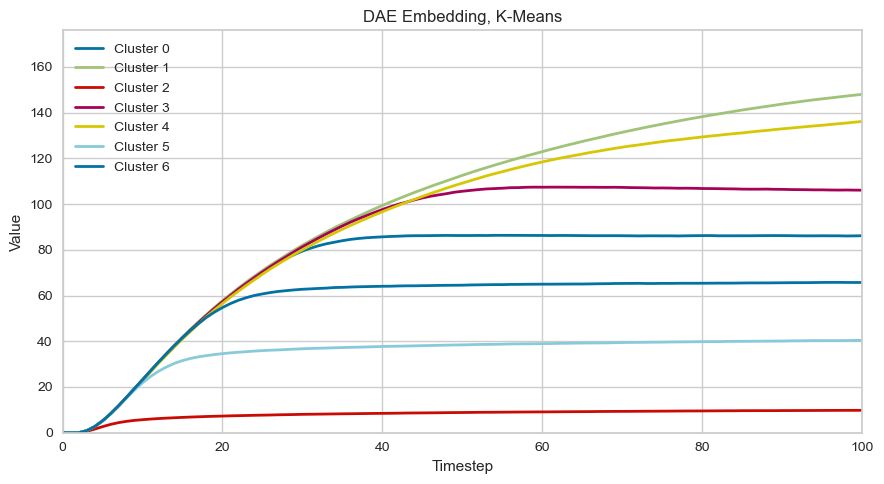

In [78]:
ts_cluster_visualization2(label_results.loc["DAE_KMeans"].to_numpy(), X_train, 7, "DAE Embedding, K-Means")
plt.savefig("dae_embedding_centers.png", format="png")

In [76]:
plt.savefig("dae_embedding_centers.png", format="png")

<Figure size 800x550 with 0 Axes>